<a href="https://colab.research.google.com/github/Vronska-Anhelina/-Prediction-and-Clustering-Models/blob/main/Predicting_Revenue_Based_on_Time_Spent_Online.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple linear regression model

1. We predict the average customer purchase income (`purchase_value`, in monetary units) based on the time spent on the site (`time_on_site`, in minutes).
2. Build a scatter plot for the input data. Assess the type of dependence, draw the regression line on the graph.
3. Split the dataset into training and test data.
4. Train a linear model on the training data and make predictions for the test data.
5. Calculate MAE, MSE, RMSE, and $R^2$ to evaluate the prediction quality on the test dataset.
6. Calculate MAE, MSE, RMSE, and $R^2$ to evaluate the prediction quality using cross-validation.
7. Draw conclusions from the obtained metric values. Consider which metric is the most indicative in this task.

In [ ]:
import pandas as pd

data = {
    "time_on_site": [
        29.1, 24.7, 17.6, 2.8, 45.4, 31.7, 48.2, 40.5, 15.7, 30.6, 25.2, 24.3,
        42.7, 25.6, 45.0, 24.2, 24.2, 47.4, 34.5, 47.1, 30.4, 26.6, 9.5, 3.2,
        30.4, 32.4, 19.8, 41.2, 40.1, 29.0, 42.0, 29.4, 10.8, 15.0, 20.5, 15.1,
        17.8, 37.4, 24.9, 43.3, 7.4, 15.4, 23.3, 41.0, 35.6, 41.4, 18.9, 40.2,
        33.0, 3.0
    ],
    "purchase_value": [
        396.1, 318.7, 112.3, 163.4, 624.1, 378.0, 689.4, 551.3, 234.3, 413.3,
        334.9, 351.1, 512.8, 265.4, 636.4, 356.7, 251.6, 620.6, 398.5, 551.6,
        493.9, 330.9, 174.2, 7.0, 368.3, 335.4, 308.5, 567.0, 535.9, 311.0,
        584.1, 428.4, 107.3, 221.1, 264.5, 242.2, 316.1, 498.3, 323.8, 495.6,
        115.9, 132.3, 238.3, 553.2, 307.4, 494.6, 234.6, 497.5, 424.1, 164.1
    ]
}

df = pd.DataFrame(data)

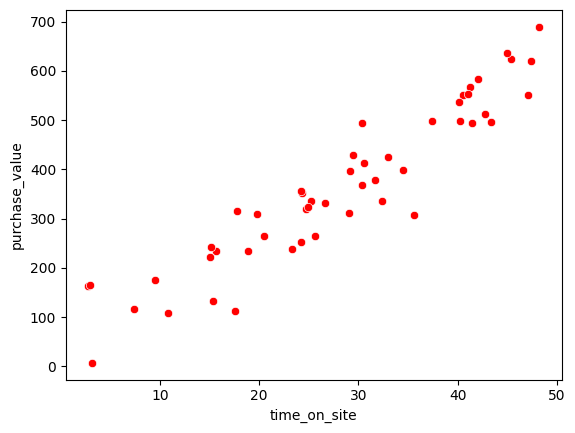

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
scatter=sns.scatterplot(data=df,x="time_on_site",y="purchase_value",color="red")
plt.show()

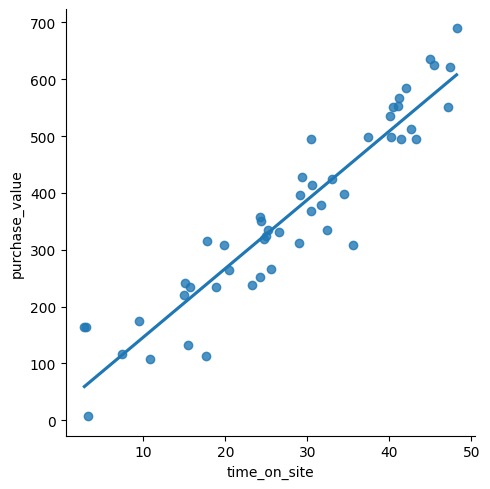

In [ ]:
sns.lmplot(data=df,x="time_on_site",y="purchase_value",ci=None)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X=df[["time_on_site"]]
y=df["purchase_value"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=2026)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f"Train date:{y_train.index}")
print(f"Test date:{y_test.index}")

Train date:Index([22,  0,  8, 44, 23, 21, 15, 34,  9, 17, 30, 19,  4, 25, 48, 16, 49, 20,
       35, 36,  7, 32, 27, 45,  2, 43, 12,  5, 28, 29, 46, 13, 26,  6,  1],
      dtype='int64')
Test date:Index([18, 38, 10, 11, 40, 33, 39, 14, 41, 24, 47, 42, 31, 37, 3], dtype='int64')


In [ ]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print(f"MAE:{mae}")
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
print(f"MSE:{mse}")
from sklearn.metrics import root_mean_squared_error
rmse=root_mean_squared_error(y_test,y_pred)
print(f"RMSE:{rmse}")
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(f"R2:{r2}")


MAE:39.57941219807053
MSE:2462.6008744997175
RMSE:49.62459948956482
R2:0.8855272566465544


In [ ]:
from sklearn.model_selection import cross_val_score
model =LinearRegression()
scores=cross_val_score(model,X,y,cv=5,scoring="neg_mean_absolute_error")
print(f"Cross-validation scores:{scores}")
print(f"Mean cross-validation score:{scores.mean()}")

Cross-validation scores:[-51.37332088 -41.63502431 -49.58701539 -36.62543402 -53.37410804]
Mean cross-validation score:-46.518980525709935


In [ ]:
model =LinearRegression()
scores=cross_val_score(model,X,y,cv=5,scoring="neg_mean_squared_error")
print(f"Cross-validation scores:{scores}")
print(f"Mean cross-validation score:{scores.mean()}")

Cross-validation scores:[-4159.91249159 -2173.77419555 -3128.12631659 -1878.90591036
 -5062.81339149]
Mean cross-validation score:-3280.7064611159817


In [ ]:
model =LinearRegression()
scores=cross_val_score(model,X,y,cv=5,scoring="r2")
print(f"Cross-validation scores:{scores}")
print(f"Mean cross-validation score:{scores.mean()}")

Cross-validation scores:[0.87353564 0.87995781 0.87713793 0.9062386  0.79112581]
Mean cross-validation score:0.8655991582416138


# Conclusion:

The diagram shows that there is a relationship between the variables, namely the average check depends on the time spent on the site. I built a model that, based on the explanatory variable (time spent on the site), shows how the target variable (average check) changes. You can make predictions on the graph how the average check will change, assessing the impact of time spent on the site on the average check, based on time.

To build a predictive model, I divided the data into training and test/validation. Using a 70-30 distribution, where 70% of the records can be used for the training part, and the other 30% for testing.

Also, the quality of the model was assessed by:
1) MAE: which shows that on average our model is "wrong" by 39.5 thousand dollars in the average check.
2) MSE: which shows that our model is wrong by 2463 thousand square dollars.
3) RMSE: which shows that our model is wrong by $49.6 thousand when calculating the average check.
4) R2: means that the model explained 88.5% of the variation in the target variable, which is a good indicator.

Also, the quality of the model was assessed using cross-validation:
1) Cross-validation of linear regression using the MAE metric indicates that the model provides moderate accuracy, with a mean absolute error of MAE of 46.5. A significant difference between the minimum error and the maximum indicates that the model is sensitive to the data.
2) Cross-validation of linear regression using the MSE metric indicates that the model provides moderate accuracy, with a mean absolute error of MSE of 3280.7. A significant difference between the minimum error and the maximum indicates that the model is sensitive to the data.